Predicting Heart Diseases


Step (1) Download and Load Dataset


In [1]:
# Task (jj) Load the CSV file
import pandas as pd
df = pd.read_csv('heart.csv')


 In this i am loading the heart disease dataset into pandas DataFrame this allows to use Python tools to analyze Dataset.

In [2]:
# Task (kk) Print shape and first 5 rows and info
print("Dataset shape: ",df.shape)
print("Dataset first five rows: ",df.head())
print("Dataset info: ", df.info())


Dataset shape:  (1025, 14)
Dataset first five rows:     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-nu

In this i am printing shape of data how many  Patient(rows) and features (columns) in data.i use head() to see first five rows of data  for a quick preview.And info() to check missing values and datatypes of each columns.

In [3]:
#Task (ll) Class distribtuion
print("Target Distribution: ")
print(df['target'].value_counts())

Target Distribution: 
target
1    526
0    499
Name: count, dtype: int64


In this  use .value_count() on target column to see how many people in our dataset have heart disease(1) and how many have not heart disease(0).It also helps to see is data balanced or if one group is much larger than the other.

Task (mm) Interpretation
Dataset is balanced because count of both classes( 0=No disease  and1=Disease) almost same.
This is supervised learning because we have 'target' labels or input features corresponding to output labels.This is classification because we have to predict categories (Yes/No) instead of continuous number.


Step (2) Exploratory Data Analysis(EDA)

In [4]:
# Task(nn)  Describe statistics  ( Data summary)
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

In this describe() function used to get a statistical summary of the dataset.This shows mean,standard deviation,minimum and maximum values
 for every column. There is huge range in cholesterol levels average 246 but maximum value is 564 which is high could be outlier or risk.


In [5]:
#Task(oo) Check for missing values
print("Missing Values: ",df.isnull().sum())

Missing Values:  age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


 In this I am checking for missing values in dataset if any data is missing model will not work correctly .This step ensure data is clean and complete for analysis.There is no missing value in this dataset.

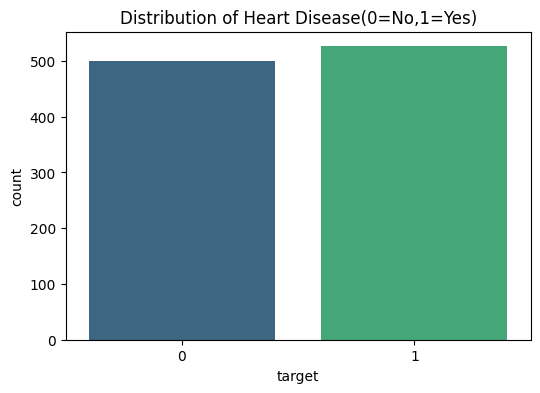

In [6]:
# Task(pp) countplot of target
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x='target',data=df, hue='target',palette='viridis',legend=False)
plt.title('Distribution of Heart Disease(0=No,1=Yes)')
plt.show()

In this i am creating Countplot to visualize balance of our target class shows how many people have heart disease versus who  are healthy.

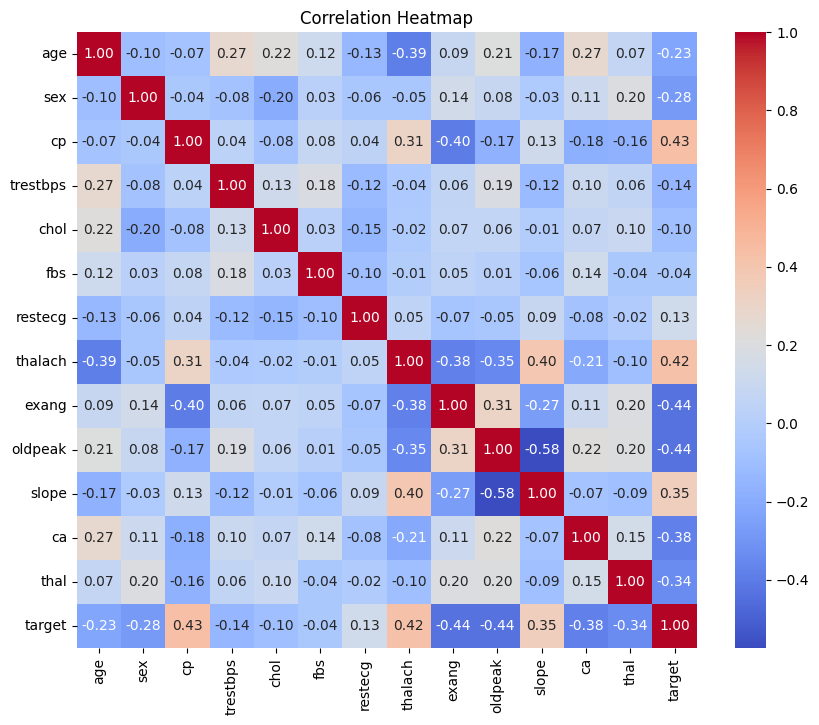

In [7]:
# Task (qq) Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In this using a Heatmap to see the relationship between all features.Darker colors show which factors are strongly connected.

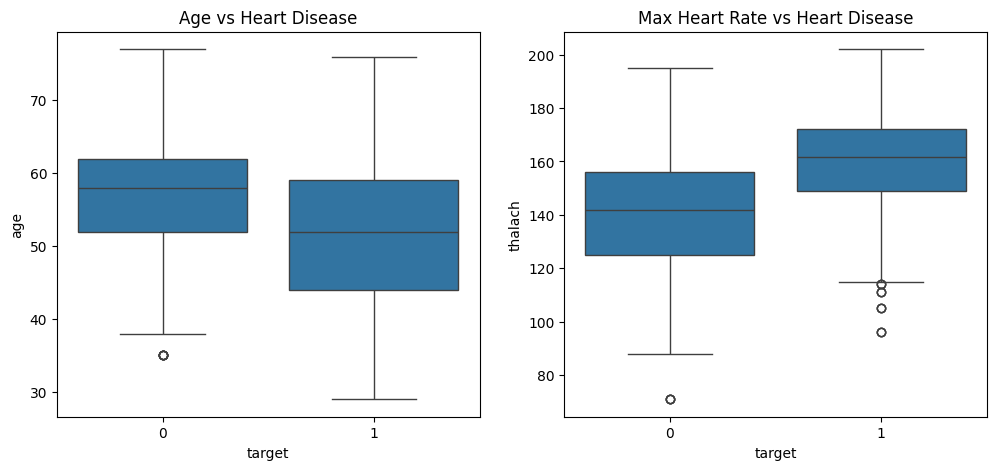

In [8]:
#Task (rr) Box plots for Age and Max Heart Rate
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='target',y='age',data=df)
plt.title('Age vs Heart Disease')
plt.subplot(1,2,2)
sns.boxplot(x='target',y='thalach',data=df)
plt.title('Max Heart Rate vs Heart Disease')
plt.show()

In this  created Boxplot for 'Age' and 'thalach'.These plots help see range and average of these values for both sick and healthy people.

Task (qq) I observed two features  cp(chest pain) and thalach(maximum heart rate)  are strongly correlated with target.Strong positive correlation of cp with target is (0.43) and thalach with target (0.42).

Task (nn) observed  significant outliers in 'chol'(75% of data under 275 but max is 564) and 'oldpeak'(75% data under 1.8 but max value is 6.2) columns because there is large gap between the 75th percentile and the maximum value

Task (rr) It is noticeable median age of  healthy  people is different from those with  heart Disease(in this data heart disease group is slightly younger) .But in Thalach vs Heart Disease people have a higher maximum heart rate as compare to those without disease.

Step (3) Data preparation and Model Training

In [9]:
# Task (ss) Separate X and y
X = df.drop('target',axis=1)
y = df['target']

In this separating the data set into two parts  features(X) and y (target value want to predict) tells the model which data to learn from and what is final answer should be.

In [10]:
# Task (tt) Split 80/20 with stratify(same ratio of 0 and 1 in both train and test)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In this step splitting data into 80% for training and 20% for testing (to prevent from overfitting) stratify=y make sure both traning and testing have same percentage of sick and healthy people random_state=42 so i get same results every time i run the code.

In [11]:
# Task (uu) Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In this using StandardScaler to normalize data (from different ranges to similar scale) helps model learn accurately give same importance to all.

In [12]:
# Task (vv) Train Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

LogisticRegression()

In this i am training Logistic Regression model this is a classification algorithm calculate probability based on input features.

In [13]:
# Task (ww)  Model Coefficients
coef_df = pd.DataFrame({'Feature':X.columns,'Coefficient':log_model.coef_[0]})
print(coef_df.sort_values(by='Coefficient',ascending=False))

     Feature  Coefficient
2         cp     0.867769
7    thalach     0.411778
10     slope     0.365533
6    restecg     0.163175
5        fbs    -0.016271
0        age    -0.116839
4       chol    -0.275126
3   trestbps    -0.362392
12      thal    -0.499174
8      exang    -0.517055
9    oldpeak    -0.614295
11        ca    -0.745506
1        sex    -0.781747


 Task(ww) I am printing Model Coefficients  to see which features affect prediction most.

Largest positive Coefficient:

This feature increases the risk of heart disease the most.cp(chest pain) 0.8677 has largest positive Coefficient .

Largest Negative Coefficient :

 This feature decreases the risk.The two  sex(-0.781) and ca (-0.745) strong  negative features.

zero Coefficient:
feature fbs(-0.016) coefficient very close to zero mean it is not consider  important  by model for prediction.

Task(xx)  The Sigmoid Function (S(z)=1/1+e^-z) is a mathematical function takes input raw score (can be from negative infinity to positive infinity) sigmoid change into probability because we need two categories(Yes/NO) if probability greater than 0.5 so classify is as Heart Disease(1) if less than 0.5 classify as Healthy(0)  helps us to take a solid decision.That's why Logistic Regression uses it.


Step (4) Prediction and Confusion matrix

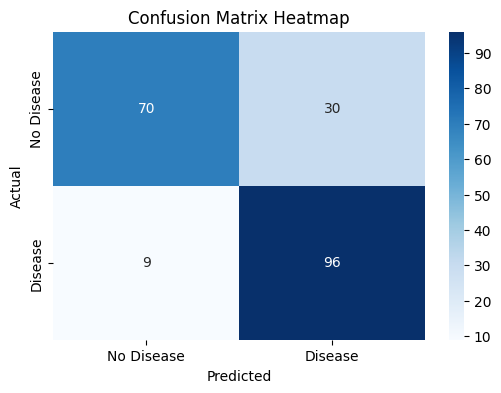

In [14]:
# Task (yy) Generate predictions
from sklearn.metrics import confusion_matrix
y_pred = log_model.predict(X_test_scaled)
# Task (zz) Display Confusion matrix as a heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()




Task (aaa)
Mannual Calculation of metrics:


TP (True Positive)=  96 correctly predicted sick(heart Disease)

FP (False Positive) = 30 (healthy but predicted as sick(heart Disease)

FN (False Negative) = 9 (missed sick)

TN (True Negative) = 70 (correctly  healthy predicted)

Total  Samples = 70+96+30+9=205

1.Accuracy=(overall correctness):

    TP+TN/Total=96+70/205=166/205=0.809 (81%)

2.Precision(Quality of positive predictions):

    TP/TP+FP=96/96+30=96/`126=0.761 (76%)

3.Recall(Ability to find sick people):
    TP/TP+FN= 96/96+9=70/105=0.914(91%)

4.F1 Score (Balance between Precision and Recall):

    2x(Precision x Recall/Precision+Recall)=2x(0.761x0.914/0.761+0.914)=0.830






In [15]:
# Task(aaa) verify sklearn's classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



My manual accuracy of 81% matches the classification report exactly.My recall(0.91) is also matches to the report's 0.91.

Task (bbb). Meaning of Each cell:
i.

True Positive(TP):

Patient HAS heart disease and model correctly said Sick.

True Negative (TN):

Patient  healthy  and model correctly said healthy (No heart disease).

False Postive(FP):

Patient is healthy but model wrongly said they are sick.

False negative(FN):

patient Has heart disease but the model wrongly said they are Healthy.




ii.Which is worse?

False Negative (FN) is much worse. model predicted as or said healthy .A sick person thinks he is safe and go home can lead to heart attack or death.

iii.
Optimize for precision or Recall?

We should optimize for Recall .In medical screening we want to correctly identified sick person as possible .It will be critical or cannot afford to miss sick patient (minimizing FN).





iv.

85% Accuracy vs 50% Recall?

This is a BAD model.Accuracy  can be misleading if model miss half of sick people. A 50 % Recall represent only half of sick people are detecting which is not accpetable.